## Chapter 2 : Working with Text Data

In [ ]:
import urllib.request

url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

urllib.request.urlretrieve(url, "the-verdict.txt")

('the-verdict.txt', <http.client.HTTPMessage at 0x78d6bac61bd0>)

In [ ]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

print("Total no of characters:", len(raw_text))
print(raw_text[:300])

Total no of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no great surprise to me to hear that, in the height of his glory, he had dropped his painting, married a rich widow, and established himself in a villa on the Riviera. (Though I rather thought it would ha


In [ ]:
len(raw_text)

20479

In [ ]:
import re
text="hello world! This, is: a test."
result=re.split(r'(\s)',text)
print (result)

['hello', ' ', 'world!', ' ', 'This,', ' ', 'is:', ' ', 'a', ' ', 'test.']


In [ ]:
result=re.split(r'([,.]|\s)',text)

In [ ]:
print(result)

['hello', ' ', 'world!', ' ', 'This', ',', '', ' ', 'is:', ' ', 'a', ' ', 'test', '.', '']


In [ ]:
result=[item for item in result if item.strip()]
print (result)

['hello', 'world!', 'This', ',', 'is:', 'a', 'test', '.']


In [ ]:
text="hello world! This, is -- a test."
result=re.split(r'([,.:;?_!"()\']|--|\s)',raw_text)
result=[item.strip() for item in result if item.strip()]
preprocessed=result

In [ ]:
len(preprocessed)

4690

In [ ]:
preprocessed[:10]

['I',
 'HAD',
 'always',
 'thought',
 'Jack',
 'Gisburn',
 'rather',
 'a',
 'cheap',
 'genius']

## 2.3 Converting tokens into token IDs

In [ ]:
text ="""It's the last he painted, you know,"
        Mrs. Gisburn said with pardonable pride."""

In [ ]:
all_words = sorted(set(preprocessed))
vocab_size=len(all_words)
print(vocab_size)

1130


In [ ]:
vocab = {token: integer for integer,token in enumerate (all_words)}
#vocab

In [ ]:
class SimpleTokenizerV1:
    def __init__(self,vocab):
        self.str_to_int=vocab
        self.int_to_str={i:s for s,i in vocab.items()}
    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed=[
            item.strip() for item in preprocessed if item.strip()
        ]
        ids=[self.str_to_int.get(s, -1) for s in preprocessed]
        return ids
    def decode(self,ids):
        text=" ".join([self.int_to_str[i] for i in ids])
        text=re.sub(r'\s+([,.?!"()\'])',r'\1', text)
        return text

In [ ]:
tokenizer=SimpleTokenizerV1(vocab)

In [ ]:
vocab["Jack"]

57

In [ ]:
int_to_str={i:s for s,i in vocab.items()}

int_to_str [57]

'Jack'

In [ ]:
ids = tokenizer.encode(text)
print(ids)

[56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [ ]:
tokenizer.decode(ids)

'It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

## 2.4 Adding special context tokens

In [ ]:
text="hello , i am learning how to build llm from scratch, is this-- a test?"
tokenizer.encode(text)

[-1, 5, -1, 150, -1, 560, 1016, -1, -1, 477, -1, 5, 584, 999, 6, 115, -1, 10]

In [ ]:
all_tokens=sorted(list(set(preprocessed)))
all_tokens.extend({"<|endoftext|>","<|unk|>"})

vocab= {token:integer for integer,token in enumerate(all_tokens)}

In [ ]:
len(vocab.items())

1132

In [ ]:
for i,item in enumerate(list(vocab.items())[-5:]):
    print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|unk|>', 1130)
('<|endoftext|>', 1131)


In [ ]:
class SimpleTokenizerV2:
    def __init__(self,vocab):
        self.str_to_int=vocab
        self.int_to_str={i:s for s,i in vocab.items()}
    def encode(self,text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)

        preprocessed=[
            item.strip() for item in preprocessed if item.strip()
        ]
        preprocessed=[
            item if item in self.str_to_int
            else "<|unk|>" for item in preprocessed
        ]
        ids=[self.str_to_int.get(s, -1) for s in preprocessed]
        return ids
    def decode(self,ids):
        text=" ".join([self.int_to_str[i] for i in ids])
        text=re.sub(r'\s+([,.?!"()\'])',r'\1', text)
        return text

In [ ]:
tokenizer=SimpleTokenizerV2(vocab)

In [ ]:
tokenizer.encode(text)

[1130,
 5,
 1130,
 150,
 1130,
 560,
 1016,
 1130,
 1130,
 477,
 1130,
 5,
 584,
 999,
 6,
 115,
 1130,
 10]

In [ ]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, <|unk|> am <|unk|> how to <|unk|> <|unk|> from <|unk|>, is this -- a <|unk|>?'

## 2.5 Byte Pair encoding

In [ ]:
import tiktoken

In [ ]:
pip install tiktoken

In [ ]:
tiktoken.__version__

'0.14.0'

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
tokenizer.encode("Hello world")

[15496, 995]

In [ ]:
tokenizer.decode(tokenizer.encode("Hello world"))

'Hello world'

In [ ]:
tokenizer.n_vocab

50257

In [ ]:
text = (
    "hello , i am learning how to build llm from scratch <|endoftext|> i hope that i learn it soon "
)
tokenizer.encode(text, allowed_special={"<|endoftext|>"})

[31373,
 837,
 1312,
 716,
 4673,
 703,
 284,
 1382,
 32660,
 76,
 422,
 12692,
 220,
 50256,
 1312,
 2911,
 326,
 1312,
 2193,
 340,
 2582,
 220]

# 2.6 Data sampling with a sliding window

In [ ]:
with open("the-verdict.txt","r",encoding="utf-8") as f:
    raw_text=f.read()

enc_text=tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [ ]:
enc_sample = enc_text[50:]

In [ ]:
len(enc_sample)

5095

In [ ]:
context_size = 4

x=enc_sample[:context_size]
y=enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [ ]:
for i in range(1,context_size+1):
    context=enc_sample[:i]
    desired=enc_sample[i]

    print(tokenizer.decode(context),"--->",tokenizer.decode([desired]))

 and --->  established
 and established --->  himself
 and established himself --->  in
 and established himself in --->  a


In [ ]:
import torch

In [ ]:
torch.__version__

'2.11.0+cu128'

In [ ]:
pip install torch

In [ ]:
from torch.utils.data import Dataset,DataLoader

class GPTDatasetV1(Dataset):
    def __init__(self,txt,tokenizer,max_length,stride):
        self.input_ids=[]
        self.target_ids=[]

        token_ids = tokenizer.encode(txt,allowed_special={"<|endoftext|>"})

        for i in range(0,len(token_ids)-max_length,stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk=token_ids[i+1: i + max_length +1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self,idx):
        return self.input_ids[idx],self.target_ids[idx]


In [ ]:
def create_dataloader_v1(txt,batch_size=2,max_length=256,stride=128,shuffle=True,drop_last=True, num_workers=0):
    tokenizer=tiktoken.get_encoding("gpt2")
    dataset=GPTDatasetV1(txt,tokenizer,max_length,stride)
    dataloader=DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=shuffle,
    drop_last=drop_last,
    num_workers=num_workers
    )

    return dataloader

In [ ]:
with open ("the-verdict.txt","r",encoding="utf-8") as f:
    raw_text=f.read()

In [ ]:
dataloader=create_dataloader_v1(
    raw_text,batch_size=1,max_length=4,stride=4,shuffle=False
)
data_iter=iter(dataloader)
first_batch=next(data_iter)
print(first_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


In [ ]:
second_batch=next(data_iter)
print(second_batch)

[tensor([[1807, 3619,  402,  271]]), tensor([[ 3619,   402,   271, 10899]])]


In [ ]:
dataloader=create_dataloader_v1(
    raw_text,batch_size=8,max_length=4,stride=4,shuffle=False
)
data_iter=iter(dataloader)
inputs,targets = next(data_iter)
print("Inputs:\n",inputs)
print("\nTargets:\n",targets)

Inputs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Targets:
 tensor([[  367,  2885,  1464,  1807],
        [ 3619,   402,   271, 10899],
        [ 2138,   257,  7026, 15632],
        [  438,  2016,   257,   922],
        [ 5891,  1576,   438,   568],
        [  340,   373,   645,  1049],
        [ 5975,   284,   502,   284],
        [ 3285,   326,    11,   287]])


## 2.7 Creating token embeddings

In [ ]:
input_ids= torch.tensor([ 2, 3, 5 , 1 ])

In [ ]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer= torch.nn.Embedding(vocab_size,output_dim)

In [ ]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [ ]:
embedding_layer(torch.tensor([3]))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)

In [ ]:
embedding_layer(torch.tensor([1]))

tensor([[0.9178, 1.5810, 1.3010]], grad_fn=<EmbeddingBackward0>)

In [ ]:
embedding_layer(input_ids)

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)

## 2.8 Encoding word positions

In [ ]:
vocab_size=50257
output_dim=256

token_embedding_layer= torch.nn.Embedding(vocab_size,output_dim)

In [ ]:
max_length = 4

dataloader = create_dataloader_v1(
    raw_text,
    batch_size=8,
    max_length=max_length,
    stride=max_length,
    shuffle=False
)
data_iter=iter(dataloader)
inputs,targets=next(data_iter)

In [ ]:
print("Token IDs:\n",inputs)
print("\nInputs shape:\n", inputs.shape)

Token IDs:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])

Inputs shape:
 torch.Size([8, 4])


In [ ]:
token_embeddings=token_embedding_layer(inputs)
token_embeddings.shape

torch.Size([8, 4, 256])

In [ ]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length ,output_dim)

In [ ]:
torch.arange(max_length)

tensor([0, 1, 2, 3])

In [ ]:
pos_embedding_layer.weight

Parameter containing:
tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       requires_grad=True)

In [ ]:
pos_embedding_layer(torch.arange(max_length))

tensor([[ 1.7375, -0.5620, -0.6303,  ..., -0.2277,  1.5748,  1.0345],
        [ 1.6423, -0.7201,  0.2062,  ...,  0.4118,  0.1498, -0.4628],
        [-0.4651, -0.7757,  0.5806,  ...,  1.4335, -0.4963,  0.8579],
        [-0.6754, -0.4628,  1.4323,  ...,  0.8139, -0.7088,  0.4827]],
       grad_fn=<EmbeddingBackward0>)

In [ ]:
pos_embeddings= pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)


torch.Size([4, 256])


In [ ]:
input_embeddings =  token_embeddings+pos_embeddings
print(input_embeddings.shape)

torch.Size([8, 4, 256])


In [ ]:
token_embeddings[0] + pos_embeddings

tensor([[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
        [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
        [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
        [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],
       grad_fn=<AddBackward0>)

In [ ]:
token_embeddings + pos_embeddings

tensor([[[ 2.2288,  0.5619,  0.8286,  ..., -0.6272, -0.2987,  0.8900],
         [ 2.0903, -0.4664, -0.0593,  ...,  0.9115, -1.0493, -1.6473],
         [-0.7158, -0.8304,  1.2494,  ...,  2.3952,  1.8773,  0.8051],
         [ 0.2703,  0.4029,  3.0514,  ...,  0.3595, -1.4548,  0.8310]],

        [[ 3.2835,  1.1749, -1.4150,  ..., -0.3281,  2.4332,  0.6924],
         [-0.2199, -0.9114, -0.1750,  ...,  1.5337, -0.1998,  0.1462],
         [ 1.5197, -1.4240,  0.4391,  ...,  1.0494, -1.4318,  2.3057],
         [ 0.2893,  0.8346, -0.1884,  ...,  1.9602,  0.8709,  0.8796]],

        [[ 0.9662,  0.0952, -0.4640,  ..., -1.0320,  1.6290,  1.7771],
         [ 2.4468, -0.2154,  1.4984,  ...,  1.8766,  0.5595, -0.1423],
         [-0.3856, -2.5393,  1.1556,  ...,  3.6157,  1.3267,  0.4944],
         [-0.2487, -0.5275,  2.0009,  ...,  0.2930,  0.5977,  1.3300]],

        ...,

        [[ 0.1219,  0.3991, -3.2740,  ..., -1.1921,  2.6637,  2.6728],
         [ 1.2438, -1.6436, -1.1101,  ..., -0.7464, -0.98

# Chapter 3 : Coding Attention Mechanism


# 3.3.1 A Simple self-attention mechanism without trainable weights

In [ ]:
import torch

inputs= torch.tensor(
[[0.43,0.15,0.89],
 [0.55,0.87,0.66],
 [0.57,0.85,0.64],
 [0.22,0.58,0.33],
 [0.77,0.25,0.10],
 [0.05,0.80,0.55]]
)

In [ ]:
input_query= inputs[1]
input_query

tensor([0.5500, 0.8700, 0.6600])

In [ ]:
input_1= inputs[0]
input_1

tensor([0.4300, 0.1500, 0.8900])

In [ ]:
torch.dot(input_query,input_1)

tensor(0.9544)

In [ ]:
res=0.
i=3

for idx,ele in enumerate(inputs[0]):
   res+=inputs[0][idx] * input_query[idx]
res

tensor(0.9544)

In [ ]:
i=1

res=torch.dot(inputs[i],input_query)
res

tensor(1.4950)

In [ ]:
query = inputs[1]
attn_scores_2=torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
    attn_scores_2[i]= torch.dot(x_i,query)

print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [ ]:
inputs.shape[0]

6

In [ ]:
attn_weights_2_tmp=attn_scores_2 / attn_scores_2.sum()
attn_weights_2_tmp

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])

In [ ]:
attn_weights_2_tmp.sum()

tensor(1.0000)

In [ ]:
def softmax_naive(x):
    return torch.exp(x) / torch.exp(x).sum(dim=0)

softmax_naive(attn_scores_2)


tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

In [ ]:
torch.softmax(attn_scores_2,dim=0)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

In [ ]:
query = inputs[1]

context_vec_2 =  torch.zeros(query.shape)
for i,x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2_tmp[i]*x_i
print(context_vec_2)

tensor([0.4355, 0.6451, 0.5680])


In [ ]:
for i,x_i in enumerate(inputs):
    print(x_i)

tensor([0.4300, 0.1500, 0.8900])
tensor([0.5500, 0.8700, 0.6600])
tensor([0.5700, 0.8500, 0.6400])
tensor([0.2200, 0.5800, 0.3300])
tensor([0.7700, 0.2500, 0.1000])
tensor([0.0500, 0.8000, 0.5500])


# 3.3.2 A simple self-attention mechanism without trainable weights

In [ ]:
attn_scores=inputs @ inputs.T
attn_weights =  torch.softmax(attn_scores,dim=1)
all_context_vecs= attn_weights @ inputs
all_context_vecs

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

# 3.4.1 Computing the attention weights step by step

In [ ]:
x_2=inputs[1]
d_in = inputs.shape[1]
d_out=2

In [ ]:
torch.manual_seed(123)

W_query= torch.nn.Parameter(torch.rand(d_in,d_out))
W_key=torch.nn.Parameter(torch.rand(d_in,d_out))
W_value= torch.nn.Parameter(torch.rand(d_in,d_out))

In [ ]:
query_2 = x_2 @ W_query
query_2

tensor([0.4306, 1.4551], grad_fn=<SqueezeBackward4>)

In [ ]:
W_query

Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]], requires_grad=True)

In [ ]:
keys= inputs @ W_key
value = inputs@ W_value

keys.shape

torch.Size([6, 2])

In [ ]:
keys

tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]], grad_fn=<MmBackward0>)

In [ ]:
keys_2= keys[1]
attn_scores_22 = torch.dot(query_2,keys_2)

In [ ]:
attn_scores_22

tensor(1.8524, grad_fn=<DotBackward0>)

In [ ]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
       grad_fn=<SqueezeBackward4>)

In [ ]:
d_k = keys.shape[1]
attn_weights_2=torch.softmax(attn_scores_2 / d_k**0.5,dim=-1)
attn_weights_2

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
       grad_fn=<SoftmaxBackward0>)

In [ ]:
attn_weights_2.sum()

tensor(1., grad_fn=<SumBackward0>)

In [ ]:
context_vec_2 = attn_weights_2 @ value
context_vec_2

tensor([0.3061, 0.8210], grad_fn=<SqueezeBackward4>)

# 3.4.2 Implementing a compact Self Attention class

In [ ]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_query= torch.nn.Parameter(torch.rand(d_in,d_out))
        self_W_key=torch.nn.Parameter(torch.rand(d_in,d_out))
        self_W_value = torch.nn.Parameter(torch.rand(d_in,d_out))

    def forward(self,x):
        queries = inputs @ W_query
        keys=inputs @ W_key
        values = inputs @ W_value

        attn_scores= queries @ keys.T
        attn_weights= torch.softmax(attn_scores/ d_k**0.5 , dim=-1)
        context_vec=attn_weights @ values

        return context_vec

torch.manual_seed(123)
sa_v1= SelfAttention_v1(d_in,d_out)
sa_v1(inputs)

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

In [ ]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [ ]:
m=torch.nn.Linear(2,3)
m.bias

Parameter containing:
tensor([-0.3189,  0.2240, -0.3146], requires_grad=True)

In [ ]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):
    def __init__(self,d_in,d_out,qkv_bias=False):
        super().__init__()
        self.W_query= torch.nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key =  torch.nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value =  torch.nn.Linear(d_in,d_out,bias=qkv_bias)

    def forward(self,x):
        queries = self.W_query(inputs)
        keys= self.W_key(inputs)
        values = self.W_value(inputs)

        attn_scores= queries @ keys.T
        attn_weights= torch.softmax(attn_scores/ d_k**0.5 , dim=-1)
        context_vec=attn_weights @ values

        return context_vec

torch.manual_seed(789)
sa_v2= SelfAttention_v2(d_in,d_out)
sa_v2(inputs)

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)

# 3.5.1 Applying a casual attention mask

In [ ]:
queries = sa_v2.W_query(inputs)
keys= sa_v2.W_key(inputs)
values = sa_v2.W_value(inputs)

attn_scores= queries @ keys.T
attn_weights= torch.softmax(attn_scores/ d_k**0.5 , dim=-1)

In [ ]:
attn_weights

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)

In [ ]:
context_length=  attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length,context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [ ]:
masked_simple = attn_weights * mask_simple
masked_simple

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)

In [ ]:
row_sums= masked_simple.sum(dim=-1,keepdim = True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


In [ ]:
mask=torch.triu(torch.ones(context_length,context_length),diagonal=1)
masked= attn_scores.masked_fill(mask.bool(),-torch.inf )
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [ ]:
torch.exp(torch.tensor(-999999999))

tensor(0.)

In [ ]:
torch.exp(torch.tensor(float("-inf")))

tensor(0.)

In [ ]:
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5 , dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


# 3.5.2 Masking additional weights with dropout

In [ ]:
torch.manual_seed(123)

layer=torch.nn.Dropout(0.5)

In [ ]:
example = torch.ones(6,6)
example

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])

In [ ]:
layer(example)

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])

In [ ]:
dropout_rate = 0.5
1 / (1-dropout_rate)

2.0

In [ ]:
layer(attn_weights)

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.6194, 0.6206, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.4925, 0.4638, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.3941, 0.0000],
        [0.3869, 0.3327, 0.0000, 0.3084, 0.3331, 0.3058]],
       grad_fn=<MulBackward0>)

# 3.5.3 Implementing a compact casual self-attention class

In [ ]:
batch = torch.stack((inputs,inputs),dim=0)
batch.shape

torch.Size([2, 6, 3])

In [ ]:
import torch.nn as nn

class CasualAttention(nn.Module):

    def __init__(self,d_in,d_out,context_length, dropout, qkv_bias=False):
        super().__init__()
        self.W_query= torch.nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_key =  torch.nn.Linear(d_in,d_out,bias=qkv_bias)
        self.W_value =  torch.nn.Linear(d_in,d_out,bias=qkv_bias)
        self.dropout =  torch.nn.Dropout(dropout)
        self.register_buffer("mask",torch.triu(torch.ones(context_length,context_length) ,diagonal=1))

    def forward(self,x):
        b, num_tokens , d_in = x.shape
        queries = self.W_query(x)
        keys= self.W_key(x)
        values = self.W_value(x)

        attn_scores= queries @ keys.transpose(1,2)
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5 , dim=-1
        )
        attn_weights = self.dropout(attn_weights)

        context_vec=attn_weights @ values

        return context_vec

torch.manual_seed(789)
context_length=batch.shape[1]
dropout= 0.0
ca = CasualAttention(d_in,d_out, context_length , dropout )
ca(batch)

tensor([[[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]],

        [[-0.0872,  0.0286],
         [-0.0991,  0.0501],
         [-0.0999,  0.0633],
         [-0.0983,  0.0489],
         [-0.0514,  0.1098],
         [-0.0754,  0.0693]]], grad_fn=<UnsafeViewBackward0>)

In [ ]:
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [ ]:
batch.shape

torch.Size([2, 6, 3])

# 3.6 Extending single head attention to multi head attention

# 3.6.1 Stacking multiple single head attention layers

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out,context_length,dropout,num_heads=2,qkv_bias=False):
        super().__init__()
        self.heads = nn.ModuleList([
        CasualAttention(d_in , d_out , context_length , dropout , qkv_bias)
        for _ in range (num_heads)
        ])

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads],dim =-1 )

torch.manual_seed(123)

context_length = batch.shape[1]
d_in, d_out = 3 ,2

mha= MultiHeadAttentionWrapper(d_in,d_out, context_length,dropout=0.0,num_heads=2)
mha(batch)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)

# 3.6.2 Implementing multi-head attention with weight splits

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out, context_length , dropout , num_heads , qkv_bias = False):
        super(). __init__()
        assert(d_out % num_heads ==0) , \
        " d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in , d_out , bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out , bias=qkv_bias)
        self.W_value = nn.Linear(d_in , d_out , bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
        "mask",
        torch.triu(torch.ones(context_length , context_length),
        diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys=self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys= keys.view(b,num_tokens,self.num_heads, self.head_dim)
        values= values.view(b, num_tokens,self.num_heads, self.head_dim)
        queries = queries.view(b,num_tokens,self.num_heads , self.head_dim)

        keys = keys.transpose(1 ,2 )
        queries = queries.transpose(1, 2 )
        values = values.transpose(1, 2)

        attn_scores = queries @  keys.transpose (2,3)

        mask_bool = self.mask.bool()[:num_tokens , :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights= torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim=-1)
        attn_weights= self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1,2)

        context_vec=context_vec.contiguous().view(b,num_tokens , self.d_out)
        context_vec= self.out_proj(context_vec)

        return context_vec

torch.manual_seed(123)

batch_size, context_length ,d_in = batch.shape
d_out = 4
mha = MultiHeadAttention(d_in , d_out , context_length , 0.0 , num_heads = 2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]],

        [[ 0.1184,  0.3120, -0.0847, -0.5774],
         [ 0.0178,  0.3221, -0.0763, -0.4225],
         [-0.0147,  0.3259, -0.0734, -0.3721],
         [-0.0116,  0.3138, -0.0708, -0.3624],
         [-0.0117,  0.2973, -0.0698, -0.3543],
         [-0.0132,  0.2990, -0.0689, -0.3490]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


# 4. Implementing a GPT model from scratch to generate text

# 4.1 Coding an LLM architecture

In [ ]:
GPT_CONFIG_124M= {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [ ]:
import torch
import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size,seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len ,device=in_idx.device))
        x=tok_embeds+pos_embeds
        x= self.drop_emb(x)
        x= self.trf_blocks(x)
        x= self.final_norm(x)
        logits = self.out_head(x)
        return logits

class DummyTransformerBlock(nn.Module):
    def __init__(self , cfg):
        super(). __init__()

    def forward(self,x):
        return x;

class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape ,eps=1e-5):
        super(). __init__()

    def forward(self,x):
        return x


In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []
txt1= "Every effort moves you"
txt2 ="Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch=torch.stack(batch, dim=0)
print (batch)

tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])


In [ ]:
batch.shape

torch.Size([2, 4])

In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(cfg=GPT_CONFIG_124M)

logits = model(batch)
print("Ouput shape:",logits.shape)
print(logits)

Ouput shape: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


# 4.2 Normalizing activations with layer normalization

In [ ]:
torch.manual_seed(123)
batch_example = torch.randn(2,100)
batch_example

tensor([[ 0.3374, -0.1778, -0.3035, -0.5880,  0.3486,  0.6603, -0.2196, -0.3792,
          0.7671, -1.1925,  0.6984, -1.4097,  0.1794,  1.8951,  0.4954,  0.2692,
         -0.0770, -1.0205, -0.1690,  0.9178,  1.5810,  1.3010,  1.2753, -0.2010,
          0.4965, -1.5723,  0.9666, -1.1481, -1.1589,  0.3255, -0.6315, -2.8400,
         -1.3250,  0.1784, -2.1338,  1.0524, -0.3885, -0.9343, -0.4991, -1.0867,
          0.8805,  1.5542,  0.6266, -0.1755,  0.0983, -0.0935,  0.2662, -0.5850,
          0.8768,  1.6221, -1.4779,  1.1331, -1.2203,  1.3139,  1.0533,  0.1388,
          2.2473, -0.8036, -0.2808,  0.7697, -0.6596, -0.7979,  0.1838,  0.2293,
          0.5146,  0.9938, -0.2587, -1.0826, -0.0444,  1.6236, -2.3229,  1.0878,
          0.6716,  0.6933, -0.9487, -0.0765, -0.1526,  0.1167,  0.4403, -1.4465,
          0.2553, -0.5496,  1.0042,  0.8272, -0.3948,  0.4892, -0.2168, -1.7472,
         -1.6025, -1.0764,  0.9031, -0.7218, -0.5951, -0.7112,  0.6230, -1.3729,
         -2.2150, -1.3193, -

In [ ]:
layer = nn.Sequential(nn.Linear(100,100),nn.ReLU())
out = layer(batch_example)
out

tensor([[0.0000, 0.0000, 0.7596, 0.5588, 0.0000, 0.0000, 0.5382, 0.0000, 0.2054,
         0.0000, 0.5107, 0.1604, 0.3479, 0.6378, 0.8569, 0.0000, 0.0423, 0.0516,
         0.4414, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.3212, 0.0000, 0.0000,
         0.8447, 0.1592, 0.0000, 0.0000, 0.6698, 0.0550, 0.0000, 0.2423, 0.0000,
         0.0000, 0.0313, 0.3183, 0.0396, 0.4979, 0.4290, 0.0698, 0.2870, 0.1595,
         0.7883, 0.0000, 0.1823, 0.0000, 0.0000, 0.9425, 0.5040, 0.6615, 0.0000,
         0.0000, 0.0718, 0.5367, 0.3890, 0.0000, 0.0000, 0.6538, 0.6955, 0.8314,
         0.0000, 0.0000, 0.8936, 0.0000, 0.0000, 0.9103, 0.0000, 0.9734, 0.0000,
         0.1423, 0.0000, 0.4092, 0.0000, 0.0000, 0.0000, 0.2176, 0.0000, 0.5356,
         0.0000, 0.1020, 0.0000, 0.6683, 0.7368, 0.5873, 0.0000, 0.0000, 0.0000,
         0.0000, 0.3593, 0.0000, 0.0000, 0.0464, 0.0000, 0.2353, 0.5605, 0.0000,
         0.1268],
        [0.0000, 0.0000, 1.0697, 0.1866, 0.6376, 0.9650, 0.0000, 0.0000, 0.0000,
         1

In [ ]:
mean=out.mean(dim=1, keepdim=True)
mean

tensor([[0.2300],
        [0.2609]], grad_fn=<MeanBackward1>)

In [ ]:
out.shape

torch.Size([2, 100])

In [ ]:
var =out.var(dim=-1 ,keepdim= True)
var

tensor([[0.0901],
        [0.1261]], grad_fn=<VarBackward0>)

In [ ]:
normed=((out - mean) / torch.sqrt(var))
normed.var(dim=-1 ,keepdim=True)

tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)

In [ ]:
torch.set_printoptions(sci_mode = False)

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self , emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self , x):
        mean=x.mean(dim=-1 ,keepdim = True)
        var = x.var(dim=-1 , keepdim = True , unbiased = False)
        norm_x = (x- mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [ ]:
ln = LayerNorm(100)
outputs_normed = ln(out)

In [ ]:
outputs_normed

tensor([[-0.7699, -0.7699,  1.7733,  1.1009, -0.7699, -0.7699,  1.0319, -0.7699,
         -0.0824, -0.7699,  0.9400, -0.2331,  0.3950,  1.3652,  2.0988, -0.7699,
         -0.6284, -0.5973,  0.7079, -0.7699, -0.7699, -0.7699, -0.7699, -0.7699,
          0.3055, -0.7699, -0.7699,  2.0579, -0.2369, -0.7699, -0.7699,  1.4725,
         -0.5859, -0.7699,  0.0413, -0.7699, -0.7699, -0.6651,  0.2958, -0.6374,
          0.8969,  0.6662, -0.5361,  0.1909, -0.2360,  1.8692, -0.7699, -0.1595,
         -0.7699, -0.7699,  2.3856,  0.9173,  1.4446, -0.7699, -0.7699, -0.5294,
          1.0268,  0.5324, -0.7699, -0.7699,  1.4190,  1.5587,  2.0134, -0.7699,
         -0.7699,  2.2218, -0.7699, -0.7699,  2.2776, -0.7699,  2.4889, -0.7699,
         -0.2936, -0.7699,  0.6001, -0.7699, -0.7699, -0.7699, -0.0415, -0.7699,
          1.0233, -0.7699, -0.4284, -0.7699,  1.4674,  1.6968,  1.1964, -0.7699,
         -0.7699, -0.7699, -0.7699,  0.4329, -0.7699, -0.7699, -0.6145, -0.7699,
          0.0179,  1.1066, -

In [ ]:
outputs_normed.var(dim=1, keepdim=True)

tensor([[1.0100],
        [1.0100]], grad_fn=<VarBackward0>)

# 4.3 Implementing a feed forward network with GELU Activations

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self,x):
        return 0.5 * x * (1+torch.tanh(torch.sqrt(torch.tensor(2.0/torch.pi)) * (x+0.044715 * torch.pow(x,3))))


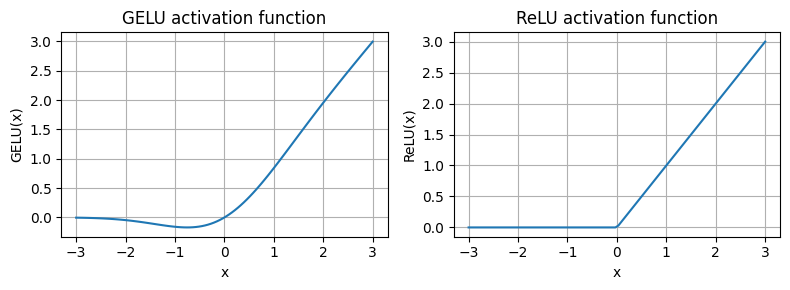

In [ ]:
import matplotlib.pyplot as plt
gelu, relu=GELU() ,nn.ReLU()

x= torch.linspace(-3,3,100)
y_gelu,y_relu= gelu(x),relu(x)

plt.figure(figsize=(8,3))
for i,(y,label) in enumerate (zip([y_gelu, y_relu], ["GELU","ReLU"]),1):
    plt.subplot(1,2,i)
    plt.plot(x,y)
    plt.title(f"{label} activation function")
    plt.xlabel("x")
    plt.ylabel(f"{label}(x)")
    plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
class FeedForward(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        self.layers = nn.Sequential(
        nn.Linear(cfg["emb_dim"],4 *cfg["emb_dim"]), GELU(),nn.Linear(4*cfg["emb_dim"] , cfg["emb_dim"]),)

    def forward(self,x):
        return self.layers(x)

In [ ]:
4*768

3072

In [ ]:
ffn=FeedForward(GPT_CONFIG_124M)

In [ ]:
x=torch.rand(2,3,768)
ffn(x).shape

torch.Size([2, 3, 768])

In [ ]:
ffn.layers[0].weight

Parameter containing:
tensor([[-0.0073,  0.0239, -0.0304,  ..., -0.0024,  0.0206, -0.0041],
        [ 0.0317,  0.0147,  0.0209,  ...,  0.0181,  0.0140,  0.0085],
        [ 0.0163,  0.0320,  0.0128,  ...,  0.0259, -0.0352,  0.0119],
        ...,
        [-0.0071,  0.0100, -0.0068,  ..., -0.0060, -0.0016, -0.0161],
        [ 0.0316, -0.0321,  0.0171,  ..., -0.0270,  0.0341,  0.0082],
        [ 0.0154, -0.0270,  0.0344,  ...,  0.0237, -0.0281, -0.0212]],
       requires_grad=True)

# 4.4 Adding shortcut connections

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self,layer_sizes,use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(layer_sizes[0],layer_sizes[1]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[1],layer_sizes[2]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[2],layer_sizes[3]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[3],layer_sizes[4]), GELU()),
        nn.Sequential(nn.Linear(layer_sizes[4],layer_sizes[5]), GELU()),])
    def forward(self,x):
        for layer in self.layers:
            layer_output= layer(x)
            if self.use_shortcut and x.shape == layer_output.shape:
                x = x+layer_output
            else:
                x= layer_output
        return x
def print_gradients(model,x):
        output= model(x)
        target= torch.tensor([[0.]])
        loss= nn.MSELoss()
        loss= loss(output,target)
        loss.backward()

        for name, param in model.named_parameters():
            if 'weight' in name:
                print(f"{name} has gradient mean of {param.grad.abs().mean().item()}")

In [ ]:
layer_sizes = [3,3,3,3,3,1]

In [ ]:
sample_input = torch.tensor([[1.,0.,-1.]])

In [ ]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes ,use_shortcut= False
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.00020173584925942123
layers.1.0.weight has gradient mean of 0.00012011159560643137
layers.2.0.weight has gradient mean of 0.0007152040489017963
layers.3.0.weight has gradient mean of 0.0013988736318424344
layers.4.0.weight has gradient mean of 0.005049645435065031


In [ ]:
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(
    layer_sizes ,use_shortcut= True
)
print_gradients(model_without_shortcut, sample_input)

layers.0.0.weight has gradient mean of 0.22169792652130127
layers.1.0.weight has gradient mean of 0.20694108307361603
layers.2.0.weight has gradient mean of 0.3289699852466583
layers.3.0.weight has gradient mean of 0.2665732204914093
layers.4.0.weight has gradient mean of 1.3258541822433472


# 4.5 Connecting attention and linear layers in a transformer block

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att= MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out= cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"])
        self.ff=FeedForward(cfg)
        self.norm1=LayerNorm(cfg["emb_dim"])
        self.norm2=LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self,x):
        shortcut =x
        x= self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x+shortcut

        shortcut=x
        x= self.norm1(x)
        x= self.att(x)
        x= x+shortcut

        shortcut= x
        x= self.norm2(x)
        x= self.ff(x)
        x= self.drop_shortcut(x)
        x=x+ shortcut

        return x



In [ ]:
torch.manual_seed(123)

x=torch.rand(2,4,768)
block= TransformerBlock(GPT_CONFIG_124M)
output=block(x)

In [ ]:
x.shape

torch.Size([2, 4, 768])

In [ ]:
output.shape

torch.Size([2, 4, 768])

# 4.6 Coding the GPT model

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"],cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"] , cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size,seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len ,device=in_idx.device))
        x=tok_embeds+pos_embeds
        x= self.drop_emb(x)
        x= self.trf_blocks(x)
        x= self.final_norm(x)
        logits = self.out_head(x)
        return logits

In [ ]:
torch.manual_seed(123)

model= GPTModel(GPT_CONFIG_124M)
out=model(batch)

In [ ]:
batch.shape

torch.Size([2, 4])

In [ ]:
out.shape

torch.Size([2, 4, 50257])

In [ ]:
batch.numel()

8

In [ ]:
total_params= sum(p.numel() for p in model.parameters())
total_params

163009536

In [ ]:
print(f"{total_params - model.out_head.weight.numel():,}")

124,412,160


In [ ]:
model.tok_emb.weight.shape

torch.Size([50257, 768])

In [ ]:
GPT_CONFIG_124M ={
    "vocab_size": 50287,
    "context_length": 1024,
    "emb_dim":768,
    "n_heads" :12,
    "n_layers":12,
    "drop_rate":0.1,
    "qkv_bias":False
}

# 4.7 Generating text

In [ ]:
def generate_text_simple(model,idx,max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:,-context_size:]

        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:,-1,:]
        probas=torch.softmax(logits,dim=-1)
        idx_next = torch.argmax(probas, dim=-1,keepdim=True)
        idx = torch.cat((idx,idx_next),dim=-1)
    return idx

In [ ]:
torch.argmax(torch.tensor([14,1,-2,1,15]))

tensor(4)

In [ ]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("encoded:",encoded)

encoded: [15496, 11, 314, 716]


In [ ]:
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:",encoded_tensor.shape)

encoded_tensor.shape: torch.Size([1, 4])


In [ ]:
encoded_tensor

tensor([[15496,    11,   314,   716]])

In [ ]:
out=generate_text_simple(model = model , idx= encoded_tensor, max_new_tokens= 6 ,context_size=GPT_CONFIG_124M["context_length"])

In [ ]:
out

tensor([[15496,    11,   314,   716, 23768,  7283, 46275, 14794,  3842, 38808]])

In [ ]:
tokenizer.decode((out.squeeze(0)).tolist())

'Hello, I ambaugh IT snowball arrests activity Nay'

# 5. Pretraining on unlabeled data

# 5.1 Evaluating generative text models

# 5.1.1 Using GPT to generate text

In [ ]:
#!pip install tensorflow
import tensorflow as tf
from importlib.metadata import version

pkgs= ["matplotlib","numpy","tiktoken","torch","tensorflow"]

for p in pkgs:
    print(f"{p} version: {version(p)}")

matplotlib version: 3.10.0
numpy version: 2.1.3
tiktoken version: 0.14.0
torch version: 2.11.0+cu128
tensorflow version: 2.20.0


In [ ]:
GPT_CONFIG_124M ={
    "vocab_size": 50257,   #vocabulary size
    "context_length": 256, #context length
    "emb_dim":768,         #Embedding dimension
    "n_heads" :12,         #Number of attention heads
    "n_layers":12,         #Number of layers
    "drop_rate":0.1,       #Dropout rate
    "qkv_bias":True      #Query-Key-Value bias
}

In [ ]:
import torch

torch.manual_seed(123)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = GPTModel(GPT_CONFIG_124M)
model.eval()
model.to(device)

cuda


GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=76

In [ ]:
import tiktoken

def text_to_token_ids(text,tokenizer):
    encoded= tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

In [ ]:
start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids= text_to_token_ids(start_context, tokenizer)
token_ids

tensor([[6109, 3626, 6100,  345]])

In [ ]:
def token_ids_to_text(token_ids, tokenizer):
    flat= token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

token_ids_to_text(token_ids, tokenizer)

'Every effort moves you'

In [ ]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer).to(device),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you Ohio humili stoutedi actuuras distraught aggregate Claw superficial


In [ ]:
token_ids.squeeze(0).shape

torch.Size([14])

In [ ]:
token_ids_to_text(token_ids, tokenizer)

'Every effort moves you Ohio humili stoutedi actuuras distraught aggregate Claw superficial'

# 5.1.2 Calculating the text generation loss: cross-entropy and perplexity

In [ ]:
inputs = torch.tensor ([[16833,3626,6100],[40,1107,588]]).to(device)
targets= torch.tensor ([[3626,6100,345], [1107,588,11311]]).to(device)

In [ ]:
with torch.no_grad():
    logits=model(inputs)

In [ ]:
logits.shape

torch.Size([2, 3, 50257])

In [ ]:
probas = torch.softmax(logits,dim=-1)
probas.shape

torch.Size([2, 3, 50257])

In [ ]:
probas

tensor([[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0001, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0001, 0.0000, 0.0000]]],
       device='cuda:0')

In [ ]:
token_ids= torch.argmax(probas,dim=-1,keepdim=True)
print("Token IDs:\n" ,token_ids)

Token IDs:
 tensor([[[24604],
         [24379],
         [40998]],

        [[36641],
         [11168],
         [33379]]], device='cuda:0')


In [ ]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Outputs batch 1:  Sequ Shane Encounter


In [ ]:
text_idx=0
target_probas_1= probas[text_idx ,[0,1,2] , targets[text_idx]]
print("Text 1:" , target_probas_1)


Text 1: tensor([0.0000, 0.0000, 0.0000], device='cuda:0')


In [ ]:
targets[text_idx]

tensor([3626, 6100,  345], device='cuda:0')

In [ ]:
text_idx = 1
target_probas_2= probas[text_idx, [0,1,2], targets [text_idx]]
print("Text 2:" , target_probas_2)

Text 2: tensor([0.0000, 0.0000, 0.0000], device='cuda:0')


In [ ]:
torch.log(torch.tensor(1))

tensor(0.)

In [ ]:
log_probas= torch.log(torch.cat((target_probas_1 , target_probas_2)))
print(log_probas)

tensor([-10.7276, -10.9219, -11.3937, -11.2198, -10.8981, -11.4118],
       device='cuda:0')


In [ ]:
-1*torch.mean(log_probas)

tensor(11.0955, device='cuda:0')

In [ ]:
logits.shape

torch.Size([2, 3, 50257])

In [ ]:
logits_flat = logits.flatten(0,1)
logits_flat.shape

torch.Size([6, 50257])

In [ ]:
targets_flat= targets.flatten()
targets_flat.shape

torch.Size([6])

In [ ]:

inputs = inputs.to(device)
targets = targets.to(device)

logits = model(inputs)

print("Logits shape:", logits.shape)

logits_flat = logits.flatten(0, 1)
print("Logits flat shape:", logits_flat.shape)

targets_flat = targets.flatten()
print("Targets flat shape:", targets_flat.shape)

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

print("Loss:", loss)

Logits shape: torch.Size([2, 3, 50257])
Logits flat shape: torch.Size([6, 50257])
Targets flat shape: torch.Size([6])
Loss: tensor(11.0955, device='cuda:0', grad_fn=<NllLossBackward0>)


# 5.1.3 Calculating the training and validation set losses

In [ ]:
import os
import urllib.request

file_path="the-verdict.txt"
url="https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"
if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path,"w" , encoding = "utf-8") as file:
        file.write(text_data)
else:
    with open(file_path,"r" , encoding="utf-8") as file :
        text_data= file.read()

In [ ]:
text_data[:99]

'I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no '

In [ ]:
total_characters=len(text_data)
total_tokens= len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:" ,total_tokens)

Characters: 20479
Tokens: 5145


In [ ]:
int(0.9 * len(text_data))

18431

In [ ]:

train_ratio = 0.90
split_idx=int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data= text_data[split_idx:]

In [ ]:
torch.manual_seed(123)
train_loader = create_dataloader_v1(
    train_data, batch_size=2, max_length= GPT_CONFIG_124M["context_length"], stride=GPT_CONFIG_124M["context_length"],drop_last=True,shuffle= True,num_workers=0)

val_loader = create_dataloader_v1(
    val_data , batch_size=2, max_length= GPT_CONFIG_124M["context_length"],stride= GPT_CONFIG_124M["context_length"],drop_last= False,shuffle=False, num_workers=0)

In [ ]:
print("Train loader:")
for x,y in train_loader:
    print(x.shape, y.shape)


Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [ ]:
print("Val loader:")
for x,y in val_loader:
    print(x.shape,y.shape)

Val loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [ ]:
train_tokens=0
for input_batch,target_batch in train_loader:
    train_tokens += input_batch.numel()

val_tokens=0
for input_batch, target_batch in val_loader:
    val_tokens += input_batch.numel()

print("Training tokens:" ,train_tokens)
print("Validation tokens:" , val_tokens)
print("All tokens:" , train_tokens + val_tokens)

Training tokens: 4608
Validation tokens: 512
All tokens: 5120


In [ ]:
x.numel()

512

In [ ]:
torch.cuda.is_available()

True

In [ ]:
torch.mps.is_available()

False

In [ ]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch)

    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1),
        target_batch.flatten()
    )

    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.

    if len(data_loader) == 0:
        return float("nan")

    elif num_batches is None:
        num_batches = len(data_loader)

    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):

        if i < num_batches:
            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            total_loss += loss.item()

        else:
            break

    return total_loss / num_batches

In [ ]:
torch.manual_seed(123)
with torch.no_grad():
    train_loss= calc_loss_loader(train_loader,model,device)
    val_loss= calc_loss_loader(val_loader, model ,device)

print("Training loss:" , train_loss)
print("Validation loss:" , val_loss)

Training loss: 10.969370206197103
Validation loss: 10.93130874633789


In [ ]:
torch.exp(torch.tensor([10.875]))

tensor([52838.7461])

In [ ]:
tokenizer.n_vocab

50257

# 5.2 Training an LLM

In [ ]:
def train_model_simple(model, train_loader, val_loader, optimizer, device,
                       num_epochs, eval_freq, eval_iter, start_context, tokenizer):

    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()

        for input_batch, target_batch in train_loader:

            optimizer.zero_grad()

            loss = calc_loss_batch(
                input_batch,
                target_batch,
                model,
                device
            )

            loss.backward()
            optimizer.step()

            tokens_seen += input_batch.numel()
            global_step += 1

            if global_step % eval_freq == 0:

                train_loss, val_loss = evaluate_model(
                    model,
                    train_loader,
                    val_loader,
                    device,
                    eval_iter
                )

                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)

                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )

        generate_and_print_sample(
            model,
            tokenizer,
            device,
            start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):

    model.eval()

    with torch.no_grad():

        train_loss = calc_loss_loader(
            train_loader,
            model,
            device,
            num_batches=eval_iter
        )

        val_loss = calc_loss_loader(
            val_loader,
            model,
            device,
            num_batches=eval_iter
        )

    model.train()

    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):

    model.eval()

    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(
        start_context,
        tokenizer
    ).to(device)

    with torch.no_grad():

        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

    decoded_text = token_ids_to_text(
        token_ids,
        tokenizer
    )

    print(decoded_text.replace("\n", " "))

    model.train()

In [ ]:
torch.manual_seed(123)
model=GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters() , lr=0.0004, weight_decay =0.1)

In [ ]:
num_epochs = 10
train_losses , val_losses , tokens_seen = train_model_simple(
    model,train_loader, val_loader, optimizer, device, num_epochs = num_epochs ,eval_freq =5, eval_iter = 5, start_context = "Every effort moves you" , tokenizer = tokenizer )

Ep 1 (Step 000000): Train loss 9.909, Val loss 9.974
Ep 1 (Step 000005): Train loss 8.152, Val loss 8.335
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,, the,,, the,,,,,,,,,,,,,
Ep 2 (Step 000010): Train loss 6.803, Val loss 7.126
Ep 2 (Step 000015): Train loss 6.209, Val loss 6.628
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 3 (Step 000020): Train loss 5.991, Val loss 6.572
Ep 3 (Step 000025): Train loss 5.998, Val loss 6.578
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 5.949, Val loss 6.618
Ep 4 (Step 000035): Train loss 5.971, Val loss 6.631
Every effort moves you,,,,,,,,, the,,,, the,,,,,, the,,,,,,, the,, the,, the,,,, the,,, the,,,, the
Ep 5 (Step 000040): Train loss 5.859, Val loss 6.673
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Ep 6 (Step 000045): Train loss 5.855, Val loss 6.664
Ep 6 (Step 000050): Train loss 5.904, Val loss 6.684
Every effort moves 

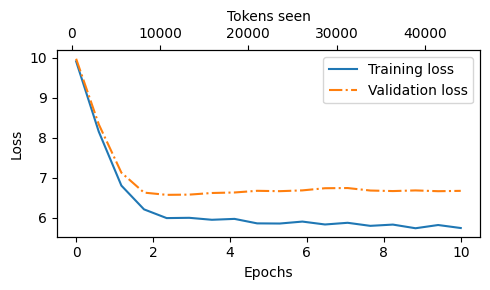

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen , tokens_seen ,train_losses , val_losses):
    fig, ax1= plt.subplots(figsize = (5,3))

    ax1.plot(epochs_seen ,train_losses , label = "Training loss")
    ax1.plot(epochs_seen, val_losses , linestyle="-." , label= "Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer= True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha =0)
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs , len(train_losses))
plot_losses(epochs_tensor , tokens_seen , train_losses , val_losses)

# 5.3 Decoding strategies to control randomness

In [ ]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model= model , idx= text_to_token_ids("Every effort moves you",tokenizer),
    max_new_tokens=25,context_size=GPT_CONFIG_124M["context_length"])
print("Output text:\n", token_ids_to_text(token_ids,tokenizer))

Output text:
 Every effort moves you,,,,, the,, the, the, the, the, the, the,, the, the I


# 5.3.1 Temperature scaling

In [ ]:
vocab ={
    "closer":0,
    "every":1,
    "effort":2,
    "forward":3,
    "inches":4,
    "moves":5,
    "pizza":6,
    "toward":7,
    "you":8,
}
inverse_vocab = {v:k for k,v in vocab.items()}
inverse_vocab


{0: 'closer',
 1: 'every',
 2: 'effort',
 3: 'forward',
 4: 'inches',
 5: 'moves',
 6: 'pizza',
 7: 'toward',
 8: 'you'}

In [ ]:
next_token_logits = torch.tensor(
    [4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79]
)

probas = torch.softmax(next_token_logits , dim=0)
probas

tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])

In [ ]:
next_token_id = torch.argmax(probas).item()
next_token_id

3

In [ ]:
inverse_vocab[next_token_id]

'forward'

In [ ]:
next_token_id = torch.multinomial(probas ,num_samples =1).item()
print(inverse_vocab[next_token_id])

closer


In [ ]:
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples =1).item() for i in range(1_000)]
  sampled_ids= torch.bincount(torch.tensor(sample))
  for i,freq in enumerate(sampled_ids):
    print(f"{freq} x {inverse_vocab[i]}")
print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [ ]:
def softmax_with_temperature(logits,temperature):
  scaled_logits = logits/temperature
  return torch.softmax(scaled_logits,dim=0)

In [ ]:
temperatures = [1,0.1,5]
scaled_probas= [softmax_with_temperature(next_token_logits,T )for T in temperatures]

In [ ]:
scaled_probas[0]

tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])

In [ ]:
probas

tensor([0.0609, 0.0016, 0.0001, 0.5721, 0.0034, 0.0001, 0.0001, 0.3576, 0.0040])

In [ ]:
scaled_probas[1].sum()

tensor(1.)

In [ ]:
scaled_probas[2].sum()

tensor(1.0000)

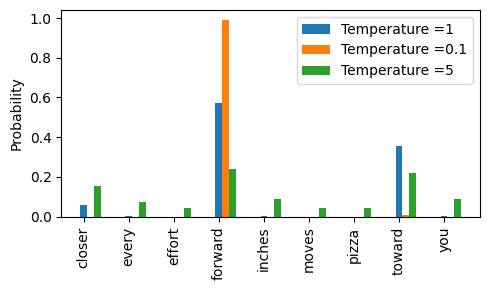

In [ ]:
x = torch.arange(len(vocab))
bar_width= 0.15

fig,ax = plt.subplots(figsize=(5,3))
for i,T in enumerate(temperatures):
  rects= ax.bar(x+i*bar_width, scaled_probas[i], bar_width,label = f'Temperature ={T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys() ,rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

# 5.3.2 Top-k Sampling

In [ ]:
next_token_logits= torch.tensor(
    [4.51,0.89,-1.90,6.75,1.63,-1.62,-1.89,6.28,1.79]
)

In [ ]:
top_k = 3
top_logits ,top_pos= torch.topk(next_token_logits, top_k)
print(top_logits, top_pos)

tensor([6.7500, 6.2800, 4.5100]) tensor([3, 7, 0])


In [ ]:
new_logits = torch.where(
    condition = next_token_logits < top_logits[-1],
    input = torch.tensor(float("-inf")),
    other= next_token_logits,

)
new_logits

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])

In [ ]:
torch.softmax(new_logits, dim=0)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])

# 5.3.3 Modifying the text generation function

In [ ]:
tokenizer.decode([50256])

'<|endoftext|>'

In [ ]:
def generate(model, idx,max_new_tokens,context_size,temperature=0.0,top_k=None,eos_id=None):
  for _ in range(max_new_tokens):
     idx_cond = idx[:, -context_size:]

     with torch.no_grad():
      logits=model(idx_cond)

      logits=logits[:, -1,:]

      if top_k is not None:
        top_logits, top_pos = torch.topk(logits, top_k)
        new_logits= torch.where(
            condition= logits < top_logits[:,-1],
            input=torch.tensor(float("-inf")),
            other=logits,
        )

      if temperature > 0.0:
        logits = logits/temperature
        probs=torch.softmax(logits, dim=-1)
        idx_next= torch.multinomial(probs,num_samples=1)

      else:
        idx_next = torch.argmax(logits, dim=-1,keepdim=True)

      if idx_next==eos_id:
        break
      idx= torch.cat((idx, idx_next), dim=1)
     return idx

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model= model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size= GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature = 1.4
)
print("Output text:\n", token_ids_to_text(token_ids,tokenizer))

Output text:
 Every effort moves youas


## 5.4 Loading and saving model weights in PyTorch

In [ ]:
torch.save(model.state_dict() , "model.pth")

# 5.5 Loading pretrained weights from OpenAI

In [ ]:

print("TensorFlow version:" , version("tensorflow"))
print("tqdm version:" , version("tqdm"))


TensorFlow version: 2.20.0
tqdm version: 4.67.3


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving gpt_download.py to gpt_download (2).py


In [ ]:
from gpt_download import download_and_load_gpt2

In [ ]:
settings,params = download_and_load_gpt2(model_size="124M",models_dir="gpt2")

File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe


In [ ]:
print("Settings:", settings)

Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [ ]:
print("Parameter dictionay keys:", params.keys())

Parameter dictionay keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [ ]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": True
}

model_configs = {
    "gpt2-small (124M)": {
        "emb_dim": 768,
        "n_layers": 12,
        "n_heads": 12
    },
    "gpt2-medium (355M)": {
        "emb_dim": 1024,
        "n_layers": 24,
        "n_heads": 16
    },
    "gpt2-large (774M)": {
        "emb_dim": 1280,
        "n_layers": 36,
        "n_heads": 20
    },
    "gpt2-xl (1558M)": {
        "emb_dim": 1600,
        "n_layers": 48,
        "n_heads": 25
    }
}

model_name = "gpt2-small (124M)"

NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({
    "context_length": 1024,
    "qkv_bias": True
})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [ ]:
def assign(left,right):
  if left.shape != right.shape:
    raise ValueError(f"Shape mismatch. Left: {left.shape} ,Right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))


In [ ]:
import numpy as np

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis=-1
        )

        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )

        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )

        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        q_b, k_b, v_b = np.split(
            params["blocks"][b]["attn"]["c_attn"]["b"], 3, axis=-1
        )

        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )

        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )

        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )

        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )

        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )

        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )

        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"]
        )

        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"]
        )

        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"]
        )

        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"]
        )

    gpt.final_norm.scale = assign(
        gpt.final_norm.scale,
        params["g"]
    )

    gpt.final_norm.shift = assign(
        gpt.final_norm.shift,
        params["b"]
    )

    gpt.out_head.weight = assign(
        gpt.out_head.weight,
        params["wte"]
    )


load_weights_into_gpt(gpt, params)
gpt.to(device);

In [ ]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you as


# Chapter 6: Training NEXA on TinyStories

The earlier chapters build the model step by step. This final section connects those ideas to the clean training files in `../nexa_124M/`. TinyStories is used here instead of the short demonstration text so that the model can learn from many simple stories.

The default below intentionally uses a small subset for a practical first run. Increase `MAX_STORIES` and `EPOCHS` after confirming that the pipeline works.


In [ ]:
# Install these once in a new notebook environment.
# %pip install -r ../requirements.txt


In [ ]:
import sys
from pathlib import Path

PROJECT_DIR = Path('../nexa_124M').resolve()
sys.path.insert(0, str(PROJECT_DIR))

import torch
import tiktoken
from model import GPTModel, ModelConfig
from train import load_text, encode_text, make_loaders, set_seed, train


In [ ]:
DATASET_NAME = 'roneneldan/TinyStories'
MAX_STORIES = 100
CONTEXT_LENGTH = 64
BATCH_SIZE = 4
EPOCHS = 1

set_seed(123)
tokenizer = tiktoken.get_encoding('gpt2')
config = ModelConfig(vocab_size=tokenizer.n_vocab, context_length=CONTEXT_LENGTH)

train_text = load_text(DATASET_NAME, 'train', MAX_STORIES)
validation_text = load_text(DATASET_NAME, 'validation', 100)
train_tokens = encode_text(train_text, tokenizer)
validation_tokens = encode_text(validation_text, tokenizer)
train_loader, validation_loader = make_loaders(
    train_tokens, validation_tokens, config, BATCH_SIZE, CONTEXT_LENGTH
)

print('training tokens:', len(train_tokens))
print('validation tokens:', len(validation_tokens))
print('training batches:', len(train_loader))


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GPTModel(config)
print('device:', device)
print('parameters:', f'{model.parameter_count():,}')

history = train(
    model, train_loader, validation_loader,
    device=device, epochs=EPOCHS, learning_rate=3e-4,
    eval_batches=5, log_every=10,
)


In [ ]:
# Save the trained weights for use by nexa_124M/chat.py.
checkpoint_path = Path('../checkpoints/tinystories_notebook.pt')
checkpoint_path.parent.mkdir(exist_ok=True)
torch.save({
    'model': model.state_dict(),
    'config': model.config_dict(),
    'history': history,
}, checkpoint_path)
print('saved:', checkpoint_path)


## Using the trained checkpoint

After the training cell finishes, the same weights can be used from the terminal:

```bash
cd ../nexa_124M
python chat.py --checkpoint ../checkpoints/tinystories_notebook.pt --prompt "Once upon a time"
```

A short run is only a pipeline check. The model needs more stories, more steps, and usually a GPU before the generated stories become coherent.
